# Healthcare Accessibility Index — Current State vs. AI Platform Scenario
### AI Regional Healthcare Coordination Platform · South Korea's Super-Aged Society

The notebook builds a 0–1 Healthcare Accessibility Index for South Korea's 17 sido
(provinces/metropolitan cities) from official statistics, projects the improvement under
the proposed AI coordination platform, and renders both as choropleth maps on a shared
color scale.

**Pipeline**

| Step | What happens | Method |
|---|---|---|
| 1 | Data assembly | 2 indicators per region, from official sources (referenced below) |
| 2 | Need adjustment | supply ÷ relative elderly burden |
| 3 | Normalization | min-max scaling → 0–1 index |
| 4 | Scenario projection | proportional gap-closure model (30%) |
| 5 | Map geometry | SVG sido boundaries → matplotlib paths |
| 6 | Visualization | two choropleths, shared RdYlGn scale |
| 7 | Verification & export | ranking cross-check, sensitivity, CSV |

**Requirements**
```
pip install numpy pandas matplotlib svgpath2mpl
npm install @svg-maps/south-korea     # map boundary geometry (MIT license)
```

## Step 1 — Data assembly (with references)

Two indicators per region:

| Column | Definition | Year | Source |
|---|---|---|---|
| `doctors_per_1k` | Doctors employed at medical institutions per 1,000 population | 2023 | KOSIS e-Regional Indicators, "인구 천명당 의료기관 종사 의사수" (Korean Statistical Information Service), https://kosis.kr |
| `pct_65plus` | Share of population aged 65+ (%) | 2025 | Ministry of the Interior and Safety (MOIS) resident registration data — national 21.2%, capital area 18.8% vs. 23.7% elsewhere (via Korea Herald, Jan 4 2026, https://www.koreaherald.com/article/10648363); regional values above 20% from Statistics Korea, *2025 Senior Statistics* (고령자 통계), https://kostat.go.kr |

**Independent cross-check** (rank validation): MOHW active-physician data submitted to the
National Assembly (July 2022) — Seoul 3.37/1,000 (highest) vs. Sejong 1.23 (lowest, a 2.73×
gap), then Gyeongbuk 1.38 and Chungnam 1.54; beds/1,000 highest in Gwangju (27.3), lowest in
Sejong (5.5). Medical World News, Oct 11 2022,
http://medicalworldnews.co.kr/m/view.php?idx=1510952343 — same regional ordering as the
KOSIS indicator used here.

`aged_est = True` rows: the 65+ share is interpolated from the MOIS capital/non-capital
aggregates because the exact per-region 2025 figure was not in the retrieved releases.


In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import PathPatch
from matplotlib.colors import Normalize
from matplotlib import cm
from svgpath2mpl import parse_path

NATIONAL_AGED = 20.3   # national 65+ share (%), 2025 — Statistics Korea
GAP_CLOSURE   = 0.30   # Step 4 scenario assumption (platform closes 30% of each gap)

# key = region id used in the SVG boundary file (enables a join with no lookup table)
DATA = {
    #  key                 name        doc/1k  65+%   65+% estimated?
    "seoul":             ("Seoul",     5.0,    20.1,  True),
    "busan":             ("Busan",     3.7,    24.5,  False),
    "daegu":             ("Daegu",     3.8,    21.2,  False),
    "incheon":           ("Incheon",   2.7,    18.0,  True),
    "gwangju":           ("Gwangju",   3.9,    18.0,  True),
    "daejeon":           ("Daejeon",   3.8,    18.3,  True),
    "ulsan":             ("Ulsan",     2.5,    17.9,  True),
    "sejong":            ("Sejong",    2.1,    11.7,  True),
    "gyeonggi":          ("Gyeonggi",  2.7,    17.0,  True),
    "gangwon":           ("Gangwon",   2.7,    25.7,  False),
    "north-chungcheong": ("Chungbuk",  2.4,    21.9,  False),
    "south-chungcheong": ("Chungnam",  2.4,    21.8,  False),
    "north-jeolla":      ("Jeonbuk",   3.2,    25.4,  False),
    "south-jeolla":      ("Jeonnam",   2.6,    27.4,  False),
    "north-gyeongsang":  ("Gyeongbuk", 2.2,    26.1,  False),
    "south-gyeongsang":  ("Gyeongnam", 2.6,    22.2,  False),
    "jeju":              ("Jeju",      2.7,    19.4,  True),
}

df = pd.DataFrame(
    [(k, *v) for k, v in DATA.items()],
    columns=["key", "region", "doctors_per_1k", "pct_65plus", "aged_est"],
).set_index("key")
df

,region,doctors_per_1k,pct_65plus,aged_est
key,,,,
seoul,Seoul,5.0,20.1,True
busan,Busan,3.7,24.5,False
daegu,Daegu,3.8,21.2,False
incheon,Incheon,2.7,18.0,True
gwangju,Gwangju,3.9,18.0,True
daejeon,Daejeon,3.8,18.3,True
ulsan,Ulsan,2.5,17.9,True
sejong,Sejong,2.1,11.7,True
gyeonggi,Gyeonggi,2.7,17.0,True


## Step 2 — Need adjustment (the "per capita effect")

Raw physician density ignores *who* the population is: 1,000 residents of Jeonnam
(27.4% elderly) generate far more care demand than 1,000 residents of Sejong (11.7%).
Each region's supply is therefore deflated by its **relative elderly burden**:

$$S_i = \frac{\text{doctors}_i}{\;\text{aged}_i / \text{aged}_{\text{national}}\;}$$

- A region with the national age structure keeps its raw density (denominator = 1).
- Jeonnam: 2.6 → **1.93** effective supply (burden ratio 1.35).
- Sejong: 2.1 → **3.64** (burden ratio 0.58 — young city, low per-capita need).

This is the simplest member of the *need-adjusted supply ratio* family used in
health-workforce research — transparent, and every input is citable.

In [2]:
df["need_ratio"]  = df["pct_65plus"] / NATIONAL_AGED
df["need_adj_supply"] = df["doctors_per_1k"] / df["need_ratio"]
df.sort_values("need_adj_supply")[["region", "doctors_per_1k", "pct_65plus",
                                   "need_ratio", "need_adj_supply"]].round(3)

,region,doctors_per_1k,pct_65plus,need_ratio,need_adj_supply
key,,,,,
north-gyeongsang,Gyeongbuk,2.2,26.1,1.286,1.711
south-jeolla,Jeonnam,2.6,27.4,1.350,1.926
gangwon,Gangwon,2.7,25.7,1.266,2.133
north-chungcheong,Chungbuk,2.4,21.9,1.079,2.225
south-chungcheong,Chungnam,2.4,21.8,1.074,2.235
south-gyeongsang,Gyeongnam,2.6,22.2,1.094,2.377
north-jeolla,Jeonbuk,3.2,25.4,1.251,2.557
jeju,Jeju,2.7,19.4,0.956,2.825
ulsan,Ulsan,2.5,17.9,0.882,2.835


## Step 3 — Normalization to the 0–1 index

Min-max scaling turns need-adjusted supply into the benchmark index:

$$\text{Index}_i = \frac{S_i - S_{\min}}{S_{\max} - S_{\min}}$$

Interpretation caveats:
- The index is **relative within Korea, within this year** — 0 = lowest need-adjusted
  supply among the 17 sido (Gyeongbuk), 1 = highest (Seoul). It does **not** mean "no access."
- Min-max (rather than z-scores) is used because a bounded 0–1 range matches the benchmark
  framing and reads intuitively on a color scale.

In [3]:
smin, smax = df["need_adj_supply"].min(), df["need_adj_supply"].max()
df["index_current"] = (df["need_adj_supply"] - smin) / (smax - smin)
df.sort_values("index_current", ascending=False)[["region", "index_current"]].round(2)

,region,index_current
key,,
seoul,Seoul,1.00
gwangju,Gwangju,0.80
daejeon,Daejeon,0.75
sejong,Sejong,0.58
daegu,Daegu,0.58
gyeonggi,Gyeonggi,0.45
busan,Busan,0.41
incheon,Incheon,0.40
ulsan,Ulsan,0.34


## Step 4 — Platform scenario projection

**Proportional gap-closure model:**

$$\text{Index}^{proj}_i = \text{Index}_i + \gamma\,(1 - \text{Index}_i), \qquad \gamma = 0.30$$

The platform adds no physicians; it raises *effective* accessibility through coordination —
**Module A** (AI triage) removes non-urgent demand from scarce ER/tertiary capacity,
**Module B** (capacity-aware routing) reallocates patients across regional facilities, and
**Module D** (telemedicine for KTAS Level 4) substitutes remote care where supply is thin.

Because the uplift is proportional to the gap, underserved regions improve most
(Gyeongbuk 0.00 → 0.30; Jeonnam 0.06 → 0.35) while Seoul stays at 1.00, the platform's
regional-equity mechanism in one line of algebra.

**Academic honesty:** γ = 0.30 is a *scenario assumption, not an estimate* - consistent with
the "modelled estimates; prospective validation required" framing in the project's
Integrated Narrative. Sensitivity at γ = 0.15 / 0.30 / 0.45 is run in Step 7.

In [4]:
df["index_projected"] = df["index_current"] + GAP_CLOSURE * (1 - df["index_current"])
df["gain"] = df["index_projected"] - df["index_current"]
df.sort_values("index_current")[["region", "index_current",
                                 "index_projected", "gain"]].round(2)

,region,index_current,index_projected,gain
key,,,,
north-gyeongsang,Gyeongbuk,0.00,0.30,0.30
south-jeolla,Jeonnam,0.06,0.35,0.28
gangwon,Gangwon,0.13,0.39,0.26
north-chungcheong,Chungbuk,0.15,0.41,0.25
south-chungcheong,Chungnam,0.16,0.41,0.25
south-gyeongsang,Gyeongnam,0.20,0.44,0.24
north-jeolla,Jeonbuk,0.25,0.48,0.22
jeju,Jeju,0.33,0.53,0.20
ulsan,Ulsan,0.34,0.54,0.20


## Step 5 — Map geometry

Boundary shapes come from the npm package **`@svg-maps/south-korea`** (MIT license,
https://www.npmjs.com/package/@svg-maps/south-korea) — 17 sido as SVG paths whose `id`s
match the `DATA` keys. Each `<path>` is parsed into a matplotlib `Path`.

Label anchors are polygon centroids (shoelace formula) computed on each region's **largest
ring**, so offshore islands don't drag the anchor into the sea. Small metropolitan cities
get manual leader-line offsets because they are too small for in-place labels.

In [5]:
SVG_FILE = "node_modules/@svg-maps/south-korea/south-korea.svg"

svg = open(SVG_FILE).read()
paths = {}
for m in re.finditer(r'<path\s+id="(.*?)"\s+aria-label=".*?"\s+d="(.*?)"', svg, re.S):
    paths[m.group(1)] = parse_path(m.group(2))
assert set(paths) == set(DATA), "SVG regions must match the data keys"

def centroid(path):
    """Area centroid (shoelace) of the largest ring of a compound path."""
    polys = path.to_polygons()
    big = max(polys, key=lambda p: abs(np.cross(p[:-1], p[1:]).sum()) / 2 if len(p) > 2 else 0)
    x, y = big[:, 0], big[:, 1]
    a = x[:-1] * y[1:] - x[1:] * y[:-1]
    A = a.sum() / 2
    if abs(A) < 1e-9:
        return big.mean(axis=0)
    return np.array([((x[:-1] + x[1:]) * a).sum() / (6 * A),
                     ((y[:-1] + y[1:]) * a).sum() / (6 * A)])

# (dx, dy) leader-line offsets in SVG units; absent regions are labeled at their centroid
OFFSETS = {
    "seoul":   (-105, -30), "incheon": (-90, 22), "daejeon": (-108, 42),
    "gwangju": (-74, 44),   "busan":   (55, 30),  "ulsan":   (54, -8),
    "daegu":   (66, 30),    "sejong":  (-114, 8), "gyeonggi": (52, -68),
}
print(f"parsed {len(paths)} region paths")

parsed 17 region paths


## Step 6 — Choropleth rendering

Design decisions:
- **Shared color scale on both maps** (`Normalize(0, 1)` + `RdYlGn`): red = poor access,
  green = good. Improvement reads as pure color intensification between the panels.
- Index values printed on every region → maps survive grayscale printing.
- The SVG y-axis points down, so y-limits are inverted; `aspect("equal")` avoids distortion.

In [6]:
cmap = plt.get_cmap("RdYlGn")
norm = Normalize(vmin=0, vmax=1)

def draw(ax, values, title, subtitle):
    for k, p in paths.items():                                   # fill
        ax.add_patch(PathPatch(p, facecolor=cmap(norm(values[k])),
                               edgecolor="white", linewidth=0.9))
    for k, p in paths.items():                                   # labels
        c = centroid(p)
        label = f"{DATA[k][0]}\n{values[k]:.2f}"
        off = OFFSETS.get(k)
        if off:
            ax.annotate(label, xy=(c[0], c[1]),
                        xytext=(c[0] + off[0], c[1] + off[1]),
                        fontsize=6.6, ha="center", va="center", color="#222",
                        arrowprops=dict(arrowstyle="-", lw=0.55, color="#666",
                                        shrinkA=0, shrinkB=1))
        else:
            ax.text(c[0], c[1], label, fontsize=6.6,
                    ha="center", va="center", color="#111")
    ax.set_xlim(-128, 615)
    ax.set_ylim(658, -80)          # inverted: SVG y grows downward
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(title, fontsize=12.5, fontweight="bold", pad=10)
    ax.text(0.5, 0.985, subtitle, transform=ax.transAxes,
            ha="center", va="bottom", fontsize=8, color="#555")

def add_cbar(fig, axes):
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    cb = fig.colorbar(sm, ax=axes, orientation="horizontal",
                      fraction=0.040, pad=0.03, aspect=42)
    cb.set_label("Healthcare Accessibility Index (0 = lowest, 1 = highest)", fontsize=9)
    cb.ax.tick_params(labelsize=8)

FOOT = ("Index: elderly-need-adjusted physician density, min-max scaled 0-1. "
        "Sources: KOSIS regional indicator - doctors per 1,000 population (2023); "
        "MOIS resident registration - share aged 65+ (2025).")

idx  = df["index_current"].to_dict()
proj = df["index_projected"].to_dict()

### Map 1 — Current state

/sessions/serene-pensive-cori/tmp/ipykernel_7/823308245.py:12: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  big = max(polys, key=lambda p: abs(np.cross(p[:-1], p[1:]).sum()) / 2 if len(p) > 2 else 0)


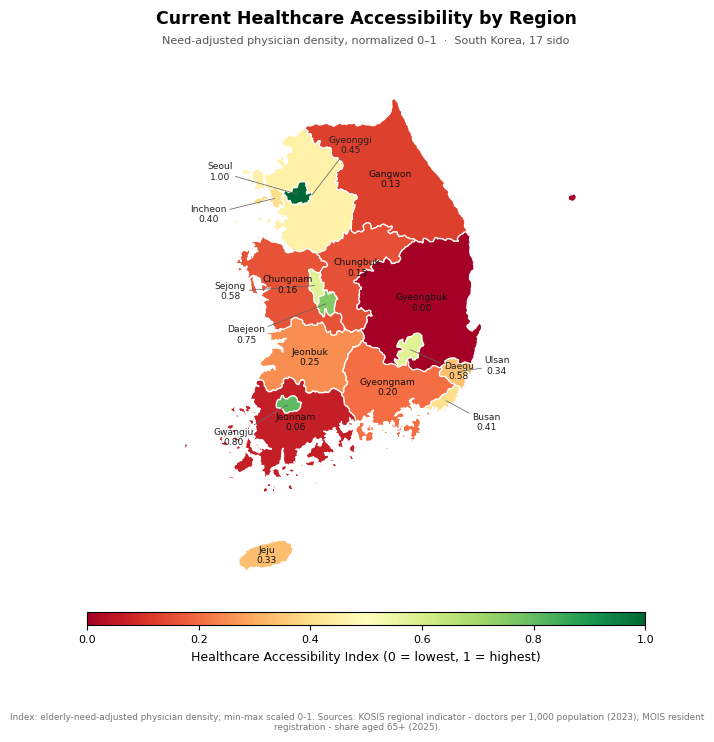

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 8.6))
draw(ax, idx, "Current Healthcare Accessibility by Region",
     "Need-adjusted physician density, normalized 0\u20131  \u00b7  South Korea, 17 sido")
add_cbar(fig, [ax])
fig.text(0.5, 0.005, FOOT, ha="center", fontsize=6.4, color="#777", wrap=True)
fig.savefig("map1_current_accessibility.png", dpi=200,
            bbox_inches="tight", facecolor="white")
plt.show()

### Map 2 — Projected with platform (30% gap-closure scenario)

/sessions/serene-pensive-cori/tmp/ipykernel_7/823308245.py:12: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  big = max(polys, key=lambda p: abs(np.cross(p[:-1], p[1:]).sum()) / 2 if len(p) > 2 else 0)


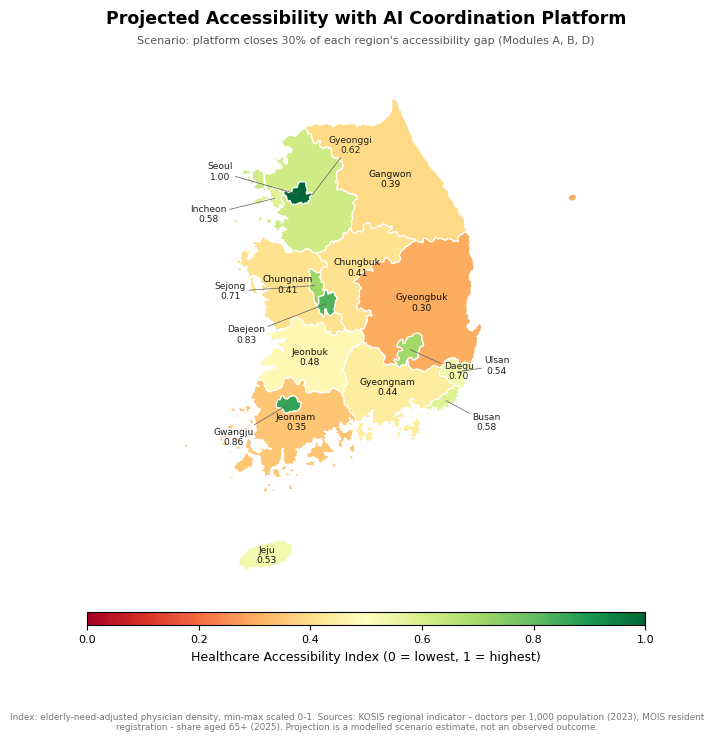

In [8]:
fig, ax = plt.subplots(figsize=(7.2, 8.6))
draw(ax, proj, "Projected Accessibility with AI Coordination Platform",
     "Scenario: platform closes 30% of each region's accessibility gap (Modules A, B, D)")
add_cbar(fig, [ax])
fig.text(0.5, 0.005,
         FOOT + " Projection is a modelled scenario estimate, not an observed outcome.",
         ha="center", fontsize=6.4, color="#777", wrap=True)
fig.savefig("map2_projected_accessibility.png", dpi=200,
            bbox_inches="tight", facecolor="white")
plt.show()

### Map 3 — Side-by-side comparison 

/sessions/serene-pensive-cori/tmp/ipykernel_7/823308245.py:12: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  big = max(polys, key=lambda p: abs(np.cross(p[:-1], p[1:]).sum()) / 2 if len(p) > 2 else 0)


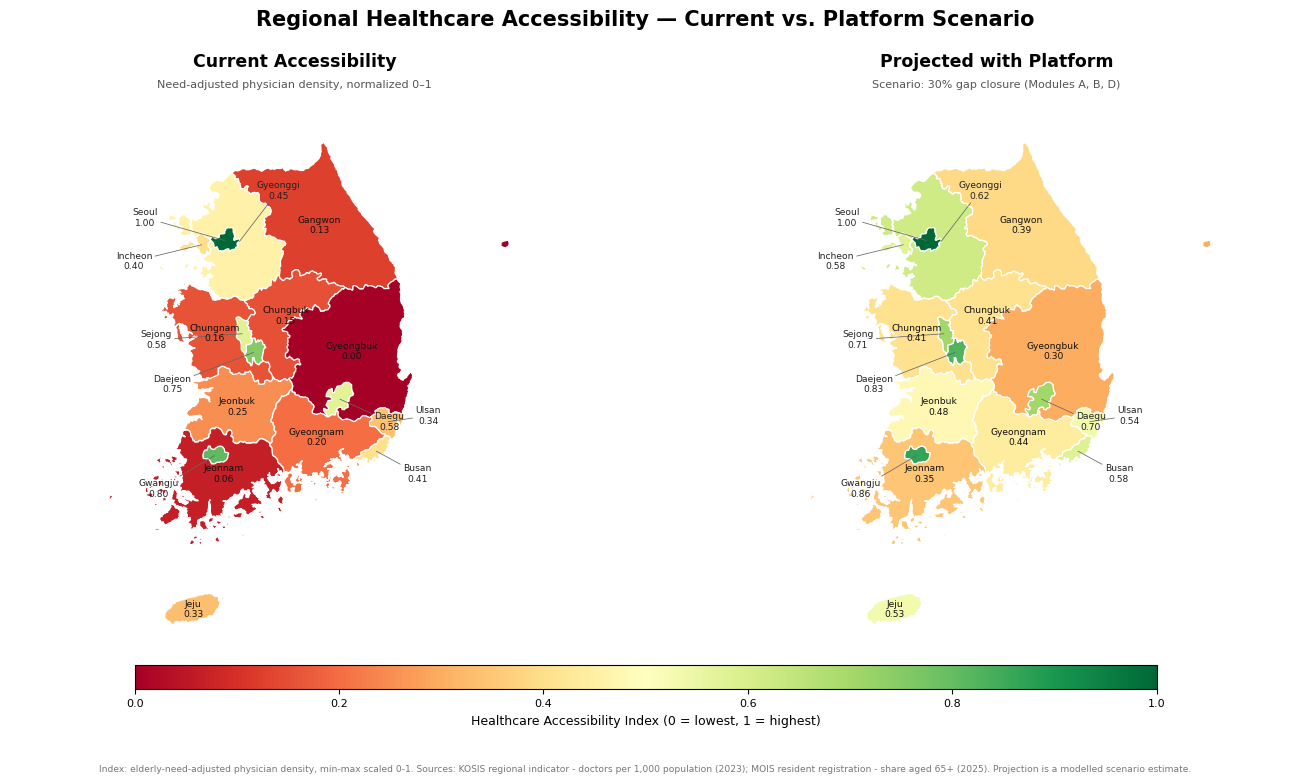

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13.4, 7.9))
fig.subplots_adjust(top=0.88, left=0.02, right=0.98)
draw(axes[0], idx,  "Current Accessibility",
     "Need-adjusted physician density, normalized 0\u20131")
draw(axes[1], proj, "Projected with Platform",
     "Scenario: 30% gap closure (Modules A, B, D)")
add_cbar(fig, axes)
fig.suptitle("Regional Healthcare Accessibility \u2014 Current vs. Platform Scenario",
             fontsize=15, fontweight="bold", y=0.97)
fig.text(0.5, 0.005, FOOT + " Projection is a modelled scenario estimate.",
         ha="center", fontsize=6.6, color="#777")
fig.savefig("map3_side_by_side.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## Step 7 — Verification, sensitivity, export

**Checks:** index bounds are exactly [0, 1]; projected ≥ current everywhere with the largest
gains in the reddest regions; and the ranking matches the independent 2022 MOHW cross-check
(Seoul highest; Sejong / Gyeongbuk / Chungnam lowest raw supply).

In [10]:
assert abs(df["index_current"].min()) < 1e-9 and abs(df["index_current"].max() - 1) < 1e-9
assert (df["index_projected"] >= df["index_current"] - 1e-9).all()
assert df.sort_values("gain", ascending=False).iloc[0]["region"] == "Gyeongbuk"

# Sensitivity: rerun the scenario at three gap-closure levels
sens = pd.DataFrame({f"gamma={g:.0%}": df["index_current"] + g * (1 - df["index_current"])
                     for g in (0.15, 0.30, 0.45)})
sens.insert(0, "region", df["region"])
sens.insert(1, "current", df["index_current"])
sens.sort_values("current").round(2)

,region,current,gamma=15%,gamma=30%,gamma=45%
key,,,,,
north-gyeongsang,Gyeongbuk,0.00,0.15,0.30,0.45
south-jeolla,Jeonnam,0.06,0.20,0.35,0.49
gangwon,Gangwon,0.13,0.26,0.39,0.52
north-chungcheong,Chungbuk,0.15,0.28,0.41,0.53
south-chungcheong,Chungnam,0.16,0.28,0.41,0.54
south-gyeongsang,Gyeongnam,0.20,0.32,0.44,0.56
north-jeolla,Jeonbuk,0.25,0.37,0.48,0.59
jeju,Jeju,0.33,0.43,0.53,0.63
ulsan,Ulsan,0.34,0.44,0.54,0.64


In [11]:
out = df[["region", "doctors_per_1k", "pct_65plus", "aged_est",
          "need_adj_supply", "index_current", "index_projected"]].round(3)
out.to_csv("accessibility_index_data.csv", index=False)
print("saved: accessibility_index_data.csv, map1/2/3 PNGs")

saved: accessibility_index_data.csv, map1/2/3 PNGs


## References

1. KOSIS (Korean Statistical Information Service), e-Regional Indicators: *Doctors employed
   at medical institutions per 1,000 population* (인구 천명당 의료기관 종사 의사수), 2023. https://kosis.kr
2. Statistics Korea, *2025 Senior Statistics* (고령자 통계) — regional 65+ shares. https://kostat.go.kr
3. Ministry of the Interior and Safety, resident registration demographics 2025 — national
   21.2% aged 65+; capital area 18.8% vs. 23.7% elsewhere. Via *Korea Herald*, Jan 4, 2026.
   https://www.koreaherald.com/article/10648363
4. Ministry of Health and Welfare data via Rep. Shin Hyun-young (National Assembly Health &
   Welfare Committee), regional active physicians / nurses / beds per 1,000, July 2022.
   *Medical World News*, Oct 11, 2022. http://medicalworldnews.co.kr/m/view.php?idx=1510952343
5. Boundary geometry: `@svg-maps/south-korea` v2.0.0 (MIT).
   https://www.npmjs.com/package/@svg-maps/south-korea